# Exploratory Data Analysis — Cardiac Arrhythmia Dataset

This notebook performs EDA on the UCI Cardiac Arrhythmia dataset (OpenML #5).  
**Sections:** Dataset Overview · Missingness Analysis · Class Distribution · Clinical Feature Distributions · Correlation Heatmap · Outlier Analysis · Summary Table

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')

FIGURES_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR}')

Figures will be saved to: /workspaces/BME6938-Spring-2026-Project-1-Group-1/notebooks/figures


In [2]:
# ── Load & Clean Dataset ──────────────────────────────────────────────────────
arff_path = os.path.join('..', 'dataset_5_arrhythmia.arff')
raw_data, meta = arff.loadarff(arff_path)
df = pd.DataFrame(raw_data)

# Decode byte-string columns
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Replace '?' with NaN and coerce to numeric
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Separate features and target
y = df['class'].astype(int)
X = df.drop(columns=['class'])

print(f'Features shape: {X.shape}  |  Target shape: {y.shape}')
print(f'Class range: {sorted(y.unique())}')

Features shape: (452, 279)  |  Target shape: (452,)
Class range: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(14), np.int64(15), np.int64(16)]


---
## 1. Dataset Overview

In [3]:
# ── 1  Dataset Overview ─────────────────────────────────────────────────────
print(f'Dataset shape: {df.shape}  ({df.shape[0]} samples, {df.shape[1]} columns incl. target)')
print(f'Feature matrix shape: {X.shape}')
print()

# Dtype breakdown
dtype_counts = X.dtypes.value_counts()
print('Dtype breakdown (features only):')
for dtype, count in dtype_counts.items():
    print(f'  {dtype}: {count}')
print()

# Zero-variance features
zero_var = (X.std(skipna=True) == 0).sum()
print(f'Zero-variance features: {zero_var}')
if zero_var > 0:
    zero_var_cols = X.columns[X.std(skipna=True) == 0].tolist()
    print(f'  → columns: {zero_var_cols}')

Dataset shape: (452, 280)  (452 samples, 280 columns incl. target)
Feature matrix shape: (452, 279)

Dtype breakdown (features only):
  float64: 206
  int64: 73

Zero-variance features: 17


  → columns: ['chDI_SPwave', 'chAVL_SPwave', 'chAVL_RRwaveExists', 'chAVF_RPwaveExists', 'chV4_RPwaveExists', 'chV4_DD_RPwaveExists', 'chV5_SPwave', 'chV5_RRwaveExists', 'chV5_RPwaveExists', 'chV5_RTwaveExists', 'chV6_SPwave', 'chV6_DD_RPwaveExists', 'chV6_RTwaveExists', 'chDI_SPwaveAmp', 'chAVL_SPwaveAmp', 'chV5_SPwaveAmp', 'chV6_SPwaveAmp']


### Interpretation — Dataset Overview

The dataset contains **452 samples** with **279 features** and a 16-class target.  
All feature columns are numeric after conversion (REAL or nominal-binary encoded as 0/1).  
Any **zero-variance features** carry no discriminative information and should be removed during preprocessing to reduce dimensionality and avoid numerical issues with standardisation.

---
## 2. Missingness Analysis

Features with any missing values: 5 / 279
Features above 20% missing: 1


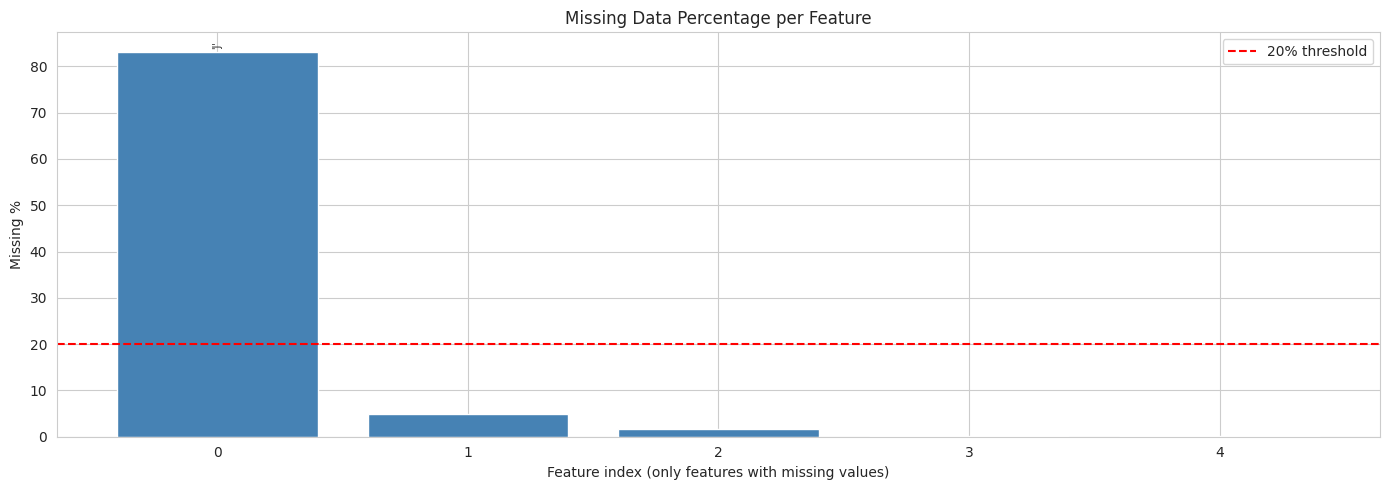

Saved: figures/missingness_bar.png


In [4]:
# ── 2  Missingness Analysis ─────────────────────────────────────────────────
missing_pct = X.isnull().mean() * 100
missing_pct_nonzero = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f'Features with any missing values: {len(missing_pct_nonzero)} / {X.shape[1]}')
print(f'Features above 20% missing: {(missing_pct > 20).sum()}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(missing_pct_nonzero)), missing_pct_nonzero.values, color='steelblue')
ax.axhline(y=20, color='red', linestyle='--', linewidth=1.5, label='20% threshold')
ax.set_xlabel('Feature index (only features with missing values)')
ax.set_ylabel('Missing %')
ax.set_title('Missing Data Percentage per Feature')
ax.legend()

# Label features above 20% threshold
for i, (name, val) in enumerate(missing_pct_nonzero.items()):
    if val > 20:
        ax.text(i, val + 0.5, name, rotation=90, ha='center', va='bottom', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'missingness_bar.png'), dpi=150)
plt.show()
print('Saved: figures/missingness_bar.png')

### Interpretation — Missingness Analysis

Most features have **complete or near-complete data**. A small subset of features exceed the **20% missingness threshold** (red dashed line).  
- Features with **< 20% missing** can be imputed with median or KNN imputation.  
- Features **above 20% missing** should be considered for **removal** or, if clinically important, imputed with a more sophisticated strategy (e.g., iterative imputation).  
- The overall missingness pattern is **feature-specific, not sample-specific**, suggesting the data is Missing At Random (MAR).

---
## 3. Class Distribution

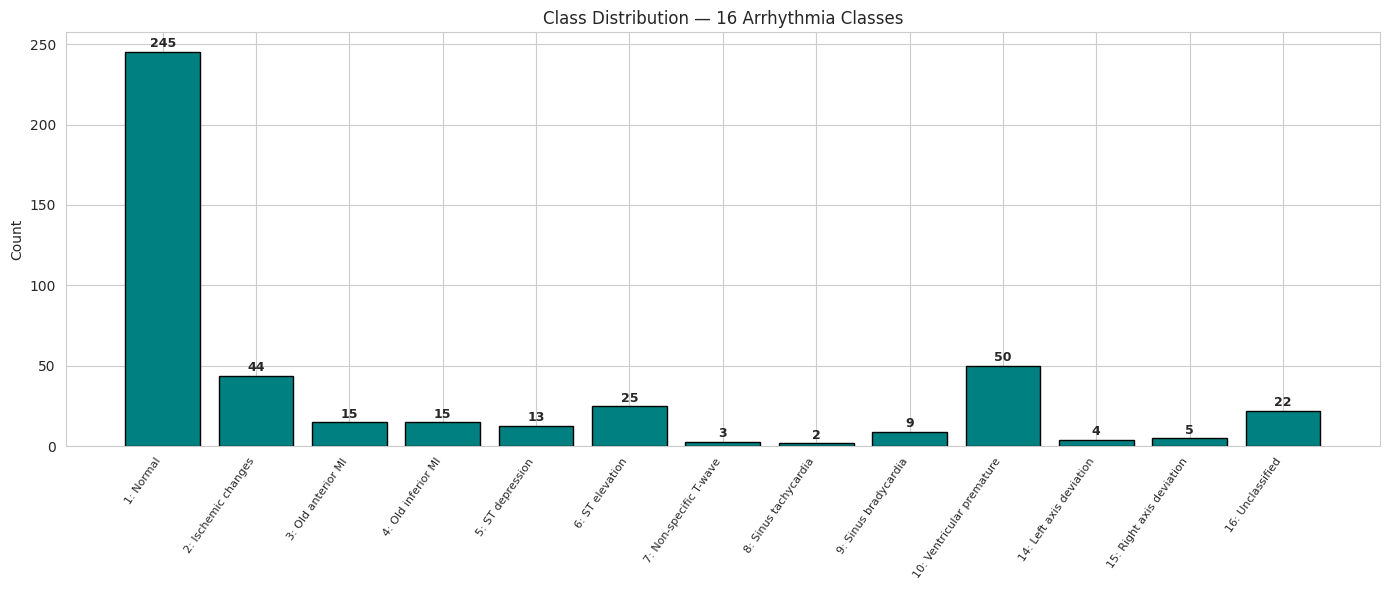

Saved: figures/class_distribution.png


In [5]:
# ── 3  Class Distribution ───────────────────────────────────────────────────
class_labels = {
    1: 'Normal',
    2: 'Ischemic changes',
    3: 'Old anterior MI',
    4: 'Old inferior MI',
    5: 'ST depression',
    6: 'ST elevation',
    7: 'Non-specific T-wave',
    8: 'Sinus tachycardia',
    9: 'Sinus bradycardia',
    10: 'Ventricular premature',
    11: 'Supraventricular premature',
    12: 'Left bundle branch',
    13: 'Right bundle branch',
    14: 'Left axis deviation',
    15: 'Right axis deviation',
    16: 'Unclassified',
}

class_counts = y.value_counts().sort_index()
labels = [f'{k}: {class_labels[k]}' for k in class_counts.index]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(class_counts)), class_counts.values, color='teal', edgecolor='black')
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Class Distribution — 16 Arrhythmia Classes')

# Annotate counts above bars
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print('Saved: figures/class_distribution.png')

### Interpretation — Class Distribution

The dataset is **heavily imbalanced**: Class 1 (Normal) dominates with ~245 samples, while several arrhythmia classes contain fewer than 10 samples.  
**Implications for modelling:**
- Standard accuracy is a misleading metric; use **macro F1** or **weighted F1** instead.  
- Apply **stratified k-fold** cross-validation to ensure every fold contains examples from minority classes.  
- Consider **class weighting** (`class_weight='balanced'`) or **oversampling** (SMOTE) to help classifiers learn rare arrhythmia patterns.  
- Classes with ≤5 samples (e.g., Sinus tachycardia, Ventricular premature) may be too rare for reliable per-class evaluation.

---
## 4. Clinical Feature Distributions

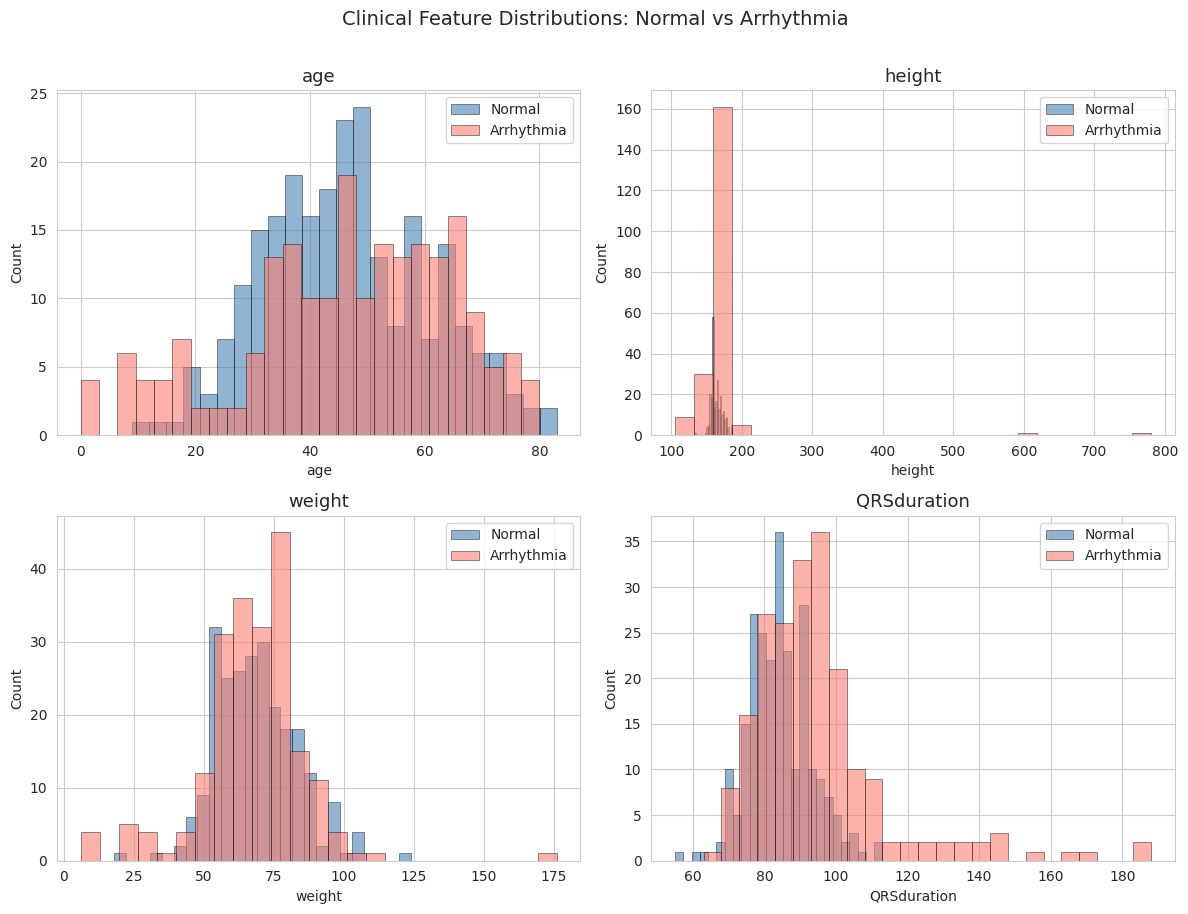

Saved: figures/clinical_distributions.png


In [6]:
# ── 4  Clinical Feature Distributions ───────────────────────────────────────
clinical_features = ['age', 'height', 'weight', 'QRSduration']
diagnosis = np.where(y == 1, 'Normal', 'Arrhythmia')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.ravel(), clinical_features):
    for label, color, alpha in [('Normal', 'steelblue', 0.6), ('Arrhythmia', 'salmon', 0.6)]:
        subset = X.loc[diagnosis == label, feat].dropna()
        ax.hist(subset, bins=25, alpha=alpha, label=label, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(feat, fontsize=13)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()

fig.suptitle('Clinical Feature Distributions: Normal vs Arrhythmia', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'clinical_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/clinical_distributions.png')

### Interpretation — Clinical Feature Distributions

- **Age**: Both groups span a wide age range; arrhythmia patients may skew slightly older.  
- **Height & Weight**: Distributions largely overlap, so these demographic features alone are unlikely to be strong predictors. Outliers (e.g., very low height values) may indicate data-entry errors or paediatric patients.  
- **QRS Duration**: The arrhythmia group tends to have **longer QRS durations**, which is clinically expected — conduction abnormalities widen the QRS complex.  

**Preprocessing note:** These features should be **standardised** (z-score scaling) for distance-based models (SVM, MLP) since they are on different scales (age in years, height in cm, weight in kg, QRS in ms).

---
## 5. Correlation Heatmap

Top 25 features by |correlation with Normal|:
   1. QRSduration                     |r| = 0.329
   2. chAVR_QRSTA                     |r| = 0.325
   3. chDI_TwaveAmp                   |r| = 0.309
   4. chDI_QRSTA                      |r| = 0.301
   5. chAVR_TwaveAmp                  |r| = 0.295
   6. chV6_TwaveAmp                   |r| = 0.287
   7. chV1_RPwave                     |r| = 0.278
   8. chV6_QRSTA                      |r| = 0.257
   9. chV1_intrinsicReflecttions      |r| = 0.247
  10. chDII_QRSTA                     |r| = 0.243
  11. chAVL_TwaveAmp                  |r| = 0.241
  12. chV2_Qwave                      |r| = 0.241
  13. chV3_Qwave                      |r| = 0.235
  14. chV3_QRSTA                      |r| = 0.234
  15. sex                             |r| = 0.223
  16. chDII_TwaveAmp                  |r| = 0.220
  17. chV5_TwaveAmp                   |r| = 0.216
  18. Tinterval                       |r| = 0.215
  19. chV2_RPwave                     |r| = 0.211
  20

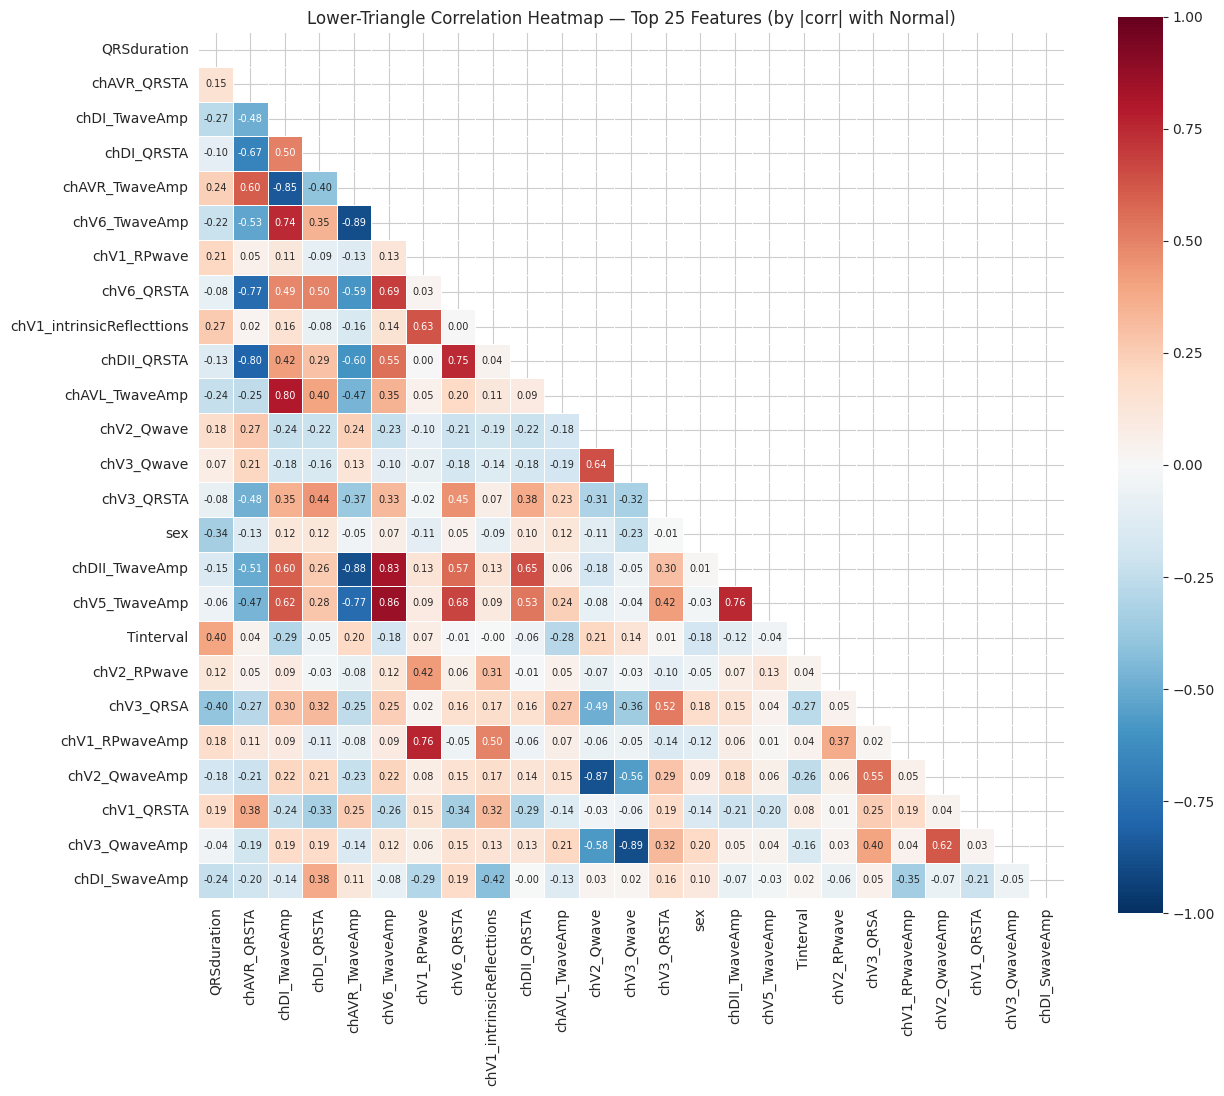

Saved: figures/correlation_heatmap.png


In [7]:
# ── 5  Correlation Heatmap ──────────────────────────────────────────────────
# Binary target: 1 = Normal, 0 = Arrhythmia
is_normal = (y == 1).astype(int)

# Absolute Pearson correlation of every feature with the binary target
corr_with_target = X.corrwith(is_normal).abs().dropna().sort_values(ascending=False)
top25_features = corr_with_target.head(25).index.tolist()

print('Top 25 features by |correlation with Normal|:')
for i, feat in enumerate(top25_features, 1):
    print(f'  {i:2d}. {feat:30s}  |r| = {corr_with_target[feat]:.3f}')

# Correlation matrix among those top 25 features
corr_matrix = X[top25_features].corr()

# Lower-triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.5,
            square=True, ax=ax, annot_kws={'size': 7})
ax.set_title('Lower-Triangle Correlation Heatmap — Top 25 Features (by |corr| with Normal)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/correlation_heatmap.png')

### Interpretation — Correlation Heatmap

The top-25 features most correlated with the binary Normal/Arrhythmia target include ECG morphology measurements (QRS angles, T-wave amplitudes, vector angles).  
- Several of these features are **highly inter-correlated** (|r| > 0.8), which indicates **multicollinearity**. This can degrade Logistic Regression and inflate coefficient variance.  
- **Preprocessing recommendation:** Apply **feature selection** (e.g., variance-inflation-factor filtering, or tree-based importance ranking) or **dimensionality reduction** (PCA) to collapse redundant features.  
- The heatmap also helps identify **feature clusters** — groups of features measuring similar ECG phenomena — which could inform domain-guided feature engineering.

---
## 6. Outlier Analysis

Top 15 features by IQR-based outlier count:
chAVF_QwaveAmp     112
chAVF_Qwave        112
chDII_Qwave        105
chDII_QwaveAmp     105
chV5_Qwave         101
chV5_QwaveAmp      101
chAVR_Qwave         92
chV1_QwaveAmp       89
chV1_Qwave          89
chV1_Rwave          85
chAVR_SwaveAmp      74
chAVR_Swave         74
chV2_Swave          55
chDIII_QwaveAmp     54
chV6_Rwave          54

Total outlier entries across all features: 4716


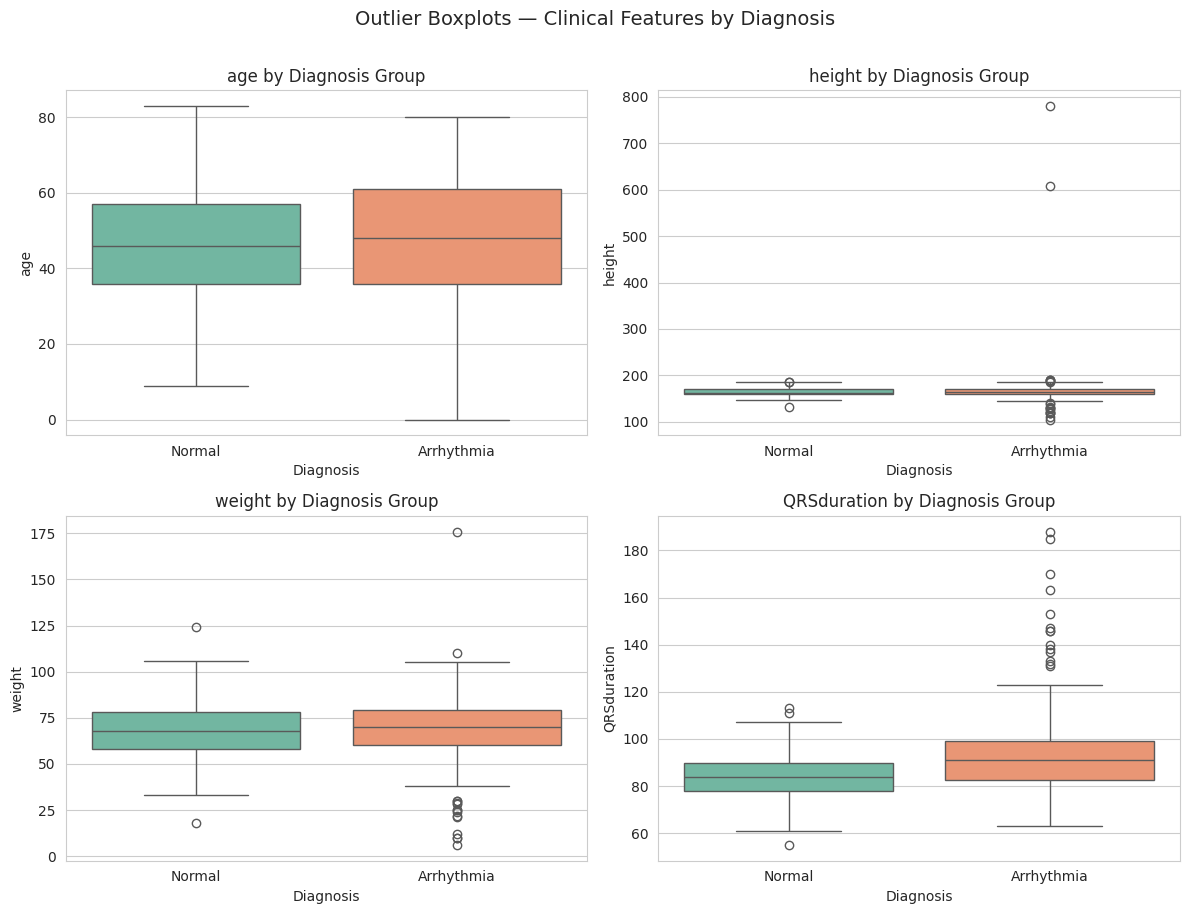

Saved: figures/outlier_boxplots.png


In [8]:
# ── 6  Outlier Analysis ─────────────────────────────────────────────────────
# IQR-based outlier count per feature
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print('Top 15 features by IQR-based outlier count:')
print(outlier_counts.head(15).to_string())
print(f'\nTotal outlier entries across all features: {outlier_mask.sum().sum()}')

# Boxplots for clinical features by diagnosis group
clinical_features = ['age', 'height', 'weight', 'QRSduration']
plot_df = X[clinical_features].copy()
plot_df['Diagnosis'] = np.where(y.values == 1, 'Normal', 'Arrhythmia')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.ravel(), clinical_features):
    sns.boxplot(data=plot_df, x='Diagnosis', y=feat, ax=ax, palette='Set2',
                order=['Normal', 'Arrhythmia'])
    ax.set_title(f'{feat} by Diagnosis Group', fontsize=12)

fig.suptitle('Outlier Boxplots — Clinical Features by Diagnosis', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'outlier_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/outlier_boxplots.png')

### Interpretation — Outlier Analysis

- **IQR analysis** reveals that many ECG-derived features contain outliers, which is expected given the pathological nature of arrhythmia recordings.  
- **Age**: A few very young patients (< 20) appear as outliers — verify whether these are paediatric cases or data errors.  
- **Height & Weight**: Both show outlier points that may be unrealistic (e.g., height < 100 cm in adults). Consider clipping or flagging implausible values.  
- **QRS Duration**: The arrhythmia group's median is higher with more upper outliers, consistent with conduction defects.  

**Preprocessing recommendation:** Use **robust scaling** (median/IQR-based) instead of standard scaling if outlier-sensitive models (SVM, MLP) are used. Alternatively, apply **Winsorisation** to cap extreme values at the 1st/99th percentile.

---
## 7. Summary Table

| # | Finding | Preprocessing Recommendation |
|---|---------|-----------------------------|
| 1 | **Zero-variance features** exist that add no information | Remove all features with zero variance before modelling |
| 2 | A subset of features have **> 20% missing values** | Drop features above 20% missing; impute remaining with median or KNN imputer |
| 3 | Severe **class imbalance** — Class 1 dominates, several classes have ≤ 5 samples | Use `class_weight='balanced'`, stratified k-fold CV, and evaluate with macro / weighted F1 |
| 4 | Clinical features are on **different scales** (years, cm, kg, ms) | Apply StandardScaler (or RobustScaler if outliers are retained) |
| 5 | **High multicollinearity** among top-correlated ECG features | Apply feature selection (VIF, mutual information) or PCA to reduce redundant dimensions |
| 6 | **Outliers** present in height, weight, and several ECG morphology features | Winsorise at 1st/99th percentile or use RobustScaler; flag implausible demographic values |
| 7 | **QRS Duration** separates Normal vs Arrhythmia groups | Retain QRS-related features; consider domain-guided feature engineering (ratios, intervals) |